# Temporal Analysis and Sequence Visualization

This notebook focuses on analyzing temporal relationships in CARLA-NavSim sequences.

## Contents
1. Setup and imports
2. Understanding temporal ordering
3. Loading sequences in temporal order
4. Temporal consistency analysis
5. Animated sequence visualization

## 1. Setup and Imports

In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.animation as animation
import pickle
import gzip
import torch
from PIL import Image
import io
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

# Define paths
base_cache_dir = Path("/workspace/navsim_workspace/exp/training_cache/")
navsim_logs_dir = Path("/workspace/navsim_workspace/dataset/navsim_logs/trainval")

## 2. Understanding Temporal Ordering

### The Challenge
- Cached tokens use hash names (e.g., `0a678d2136b35b56`) that don't reflect time order
- Alphabetical sorting of tokens ≠ temporal order

### The Solution
- Original NavSim log files contain temporal ordering
- Log files map token hashes to temporal indices
- We can reconstruct the correct time sequence

### Finding Temporal Order in Cached Data

#### The Problem
The cached data uses hash-based token names (e.g., `0a678d2136b35b56`) that don't reflect temporal order. When sorted alphabetically, tokens are NOT in time order.

#### The Solution: NavSim Log Files
The temporal ordering information exists in the original NavSim log files located at:
```
/workspace/navsim_workspace/dataset/navsim_logs/trainval/
```

Each log file contains a list of frames with:
- `token`: The hash identifier (matches the cached token directories)
- `timestamp`: The actual timestamp  
- Frame index: Position in the sequence

#### How to Extract Temporal Ordering

1. **Match sequence names**: The log file name matches the sequence directory name
   ```
   Cached: /training_cache/2021.05.12.19.36.12_veh-35_00005_00204/
   Log:    /navsim_logs/trainval/2021.05.12.19.36.12_veh-35_00005_00204.pkl
   ```

2. **Load the log file**: Contains frame objects with token and timestamp
   ```python
   with open(log_path, 'rb') as f:
       log_data = pickle.load(f)  # List of frame objects
   ```

3. **Create temporal mapping**: Map tokens to their temporal indices
   ```python
   token_to_temporal_idx = {}
   for i, frame in enumerate(log_data):
       token_to_temporal_idx[frame.token] = i
   ```

4. **Sort cached tokens**: Use the mapping to sort tokens temporally

#### Data Structure References
- Frame class definition: `navsim/common/dataclasses.py` (contains token, timestamp fields)
- Scenario loading: `navsim/planning/scenario_builder/navsim_scenario.py` line 50
- Cache creation: Tokens are sampled at 2Hz (0.5s intervals) from the original data

#### Key Insights
- The cache only contains a subset of frames from the original log (sampled at 2Hz)
- Some sequences may have gaps where frames were filtered out during caching
- The temporal ordering is essential for sequence modeling or trajectory prediction tasks
- For single-frame training, random order is typically fine

In [12]:
def extract_temporal_mapping(sequence_name):
    """Extract temporal ordering from NavSim log files."""
    log_path = navsim_logs_dir / f"{sequence_name}.pkl"
    
    if not log_path.exists():
        print(f"Warning: No log file found for {sequence_name}")
        return None
    
    # Load log data
    with open(log_path, 'rb') as f:
        log_data = pickle.load(f)
    
    # Create token to temporal index mapping
    token_to_idx = {}
    for i, frame in enumerate(log_data):
        if hasattr(frame, 'token'):
            token_to_idx[frame.token] = i
    
    return token_to_idx

# Test with first sequence
sequences = sorted([d for d in base_cache_dir.iterdir() if d.is_dir()])
if sequences:
    seq_name = sequences[0].name
    mapping = extract_temporal_mapping(seq_name)
    if mapping:
        print(f"Successfully extracted temporal mapping for {seq_name}")
        print(f"Found {len(mapping)} token mappings")

## 3. Loading Sequences in Temporal Order

In [13]:
def load_sequence_temporal(sequence_path, max_tokens=None):
    """Load sequence data in correct temporal order."""
    seq_name = sequence_path.name
    
    # Get temporal mapping
    mapping = extract_temporal_mapping(seq_name)
    
    # Get all tokens in the sequence
    token_dirs = [d for d in sequence_path.iterdir() if d.is_dir()]
    
    if mapping:
        # Sort by temporal index
        temporal_tokens = [(d, mapping.get(d.name, float('inf'))) 
                          for d in token_dirs]
        temporal_tokens = [(d, idx) for d, idx in temporal_tokens 
                          if idx != float('inf')]
        temporal_tokens.sort(key=lambda x: x[1])
        ordered_tokens = [d for d, _ in temporal_tokens]
    else:
        # Fallback to alphabetical order
        ordered_tokens = sorted(token_dirs, key=lambda x: x.name)
    
    # Load data
    if max_tokens:
        ordered_tokens = ordered_tokens[:max_tokens]
    
    data = []
    for token_dir in ordered_tokens:
        try:
            with gzip.open(token_dir / "transfuser_feature.gz", 'rb') as f:
                features = pickle.load(f)
            with gzip.open(token_dir / "transfuser_target.gz", 'rb') as f:
                targets = pickle.load(f)
            
            data.append({
                'token': token_dir.name,
                'features': features,
                'targets': targets
            })
        except Exception as e:
            print(f"Error loading {token_dir.name}: {e}")
    
    return data

# Load first 10 frames of a sequence
if sequences:
    temporal_data = load_sequence_temporal(sequences[0], max_tokens=10)
    print(f"Loaded {len(temporal_data)} frames in temporal order")

Loaded 6 frames in temporal order


## 4. Temporal Consistency Analysis

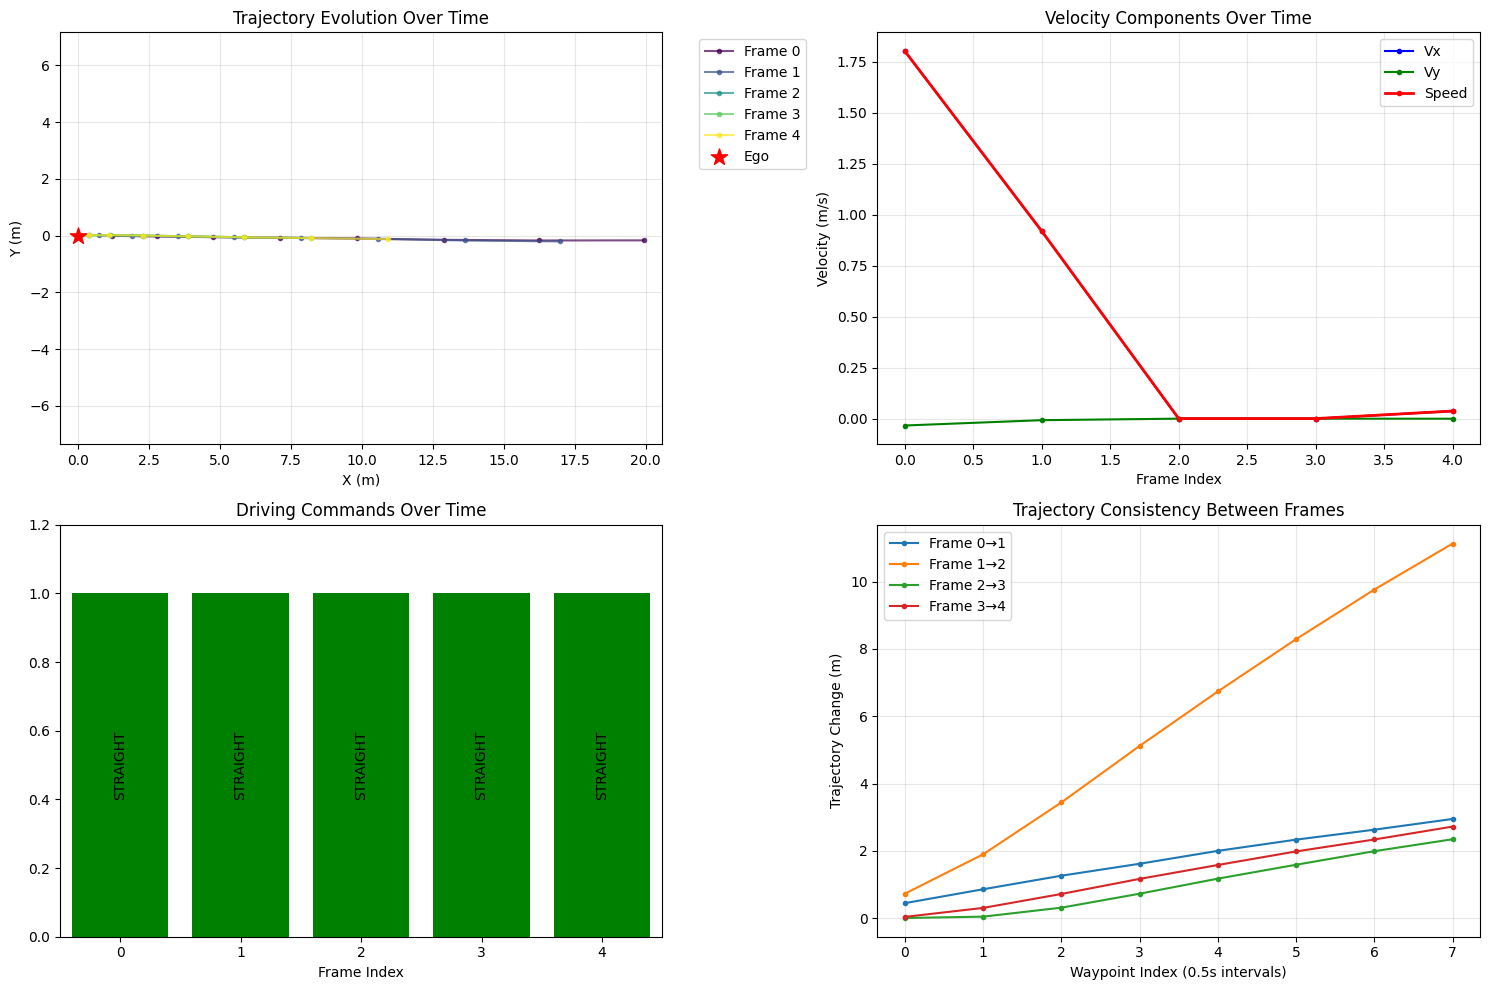


Temporal Statistics:
Average speed: 0.55 m/s
Speed variation: 0.72 m/s
Command changes: 0 times


In [14]:
def analyze_temporal_consistency(sequence_data, figsize=(15, 10)):
    """Analyze how predictions evolve over time."""
    if len(sequence_data) < 2:
        print("Need at least 2 frames for temporal analysis")
        return
    
    # Extract data
    trajectories = []
    velocities = []
    commands = []
    
    for frame in sequence_data:
        traj = frame['targets']['trajectory'].numpy()
        status = frame['features']['status_feature'].numpy()
        
        trajectories.append(traj)
        velocities.append([status[4], status[5]])  # vx, vy at indices 4,5
        commands.append(np.argmax(status[0:4]))     # commands at indices 0-3
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # 1. Trajectory evolution
    ax1 = axes[0, 0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(trajectories)))
    
    for i, (traj, color) in enumerate(zip(trajectories, colors)):
        ax1.plot(traj[:, 0], traj[:, 1], '.-', color=color, 
                label=f'Frame {i}', alpha=0.7)
    
    ax1.scatter(0, 0, c='red', s=150, marker='*', label='Ego', zorder=10)
    ax1.set_xlabel('X (m)')
    ax1.set_ylabel('Y (m)')
    ax1.set_title('Trajectory Evolution Over Time')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.axis('equal')
    
    # 2. Velocity profile
    ax2 = axes[0, 1]
    velocities = np.array(velocities)
    speeds = np.sqrt(velocities[:, 0]**2 + velocities[:, 1]**2)
    
    frames = np.arange(len(velocities))
    ax2.plot(frames, velocities[:, 0], 'b.-', label='Vx')
    ax2.plot(frames, velocities[:, 1], 'g.-', label='Vy')
    ax2.plot(frames, speeds, 'r.-', label='Speed', linewidth=2)
    ax2.set_xlabel('Frame Index')
    ax2.set_ylabel('Velocity (m/s)')
    ax2.set_title('Velocity Components Over Time')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3. Command sequence
    ax3 = axes[1, 0]
    cmd_names = ['LEFT', 'STRAIGHT', 'RIGHT', 'UNKNOWN']
    cmd_colors = ['orange', 'green', 'blue', 'red']
    
    for i, cmd in enumerate(commands):
        ax3.bar(i, 1, color=cmd_colors[cmd], width=0.8)
        ax3.text(i, 0.5, cmd_names[cmd], ha='center', va='center', 
                rotation=90 if len(cmd_names[cmd]) > 6 else 0)
    
    ax3.set_xlabel('Frame Index')
    ax3.set_title('Driving Commands Over Time')
    ax3.set_ylim(0, 1.2)
    ax3.set_xlim(-0.5, len(commands) - 0.5)
    
    # 4. Trajectory consistency
    ax4 = axes[1, 1]
    
    # Calculate trajectory changes between frames
    traj_changes = []
    for i in range(1, len(trajectories)):
        change = np.linalg.norm(trajectories[i] - trajectories[i-1], axis=1)
        traj_changes.append(change)
    
    traj_changes = np.array(traj_changes)
    waypoints = np.arange(traj_changes.shape[1])
    
    for i, change in enumerate(traj_changes):
        ax4.plot(waypoints, change, '.-', 
                label=f'Frame {i}→{i+1}')
    
    ax4.set_xlabel('Waypoint Index (0.5s intervals)')
    ax4.set_ylabel('Trajectory Change (m)')
    ax4.set_title('Trajectory Consistency Between Frames')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\nTemporal Statistics:")
    print(f"Average speed: {np.mean(speeds):.2f} m/s")
    print(f"Speed variation: {np.std(speeds):.2f} m/s")
    print(f"Command changes: {np.sum(np.diff(commands) != 0)} times")

# Analyze temporal consistency
if sequences and temporal_data:
    analyze_temporal_consistency(temporal_data[:5])

In [15]:
import warnings
warnings.filterwarnings('ignore', message='Ignoring fixed y limits')

def create_temporal_sequence_animation(sequence_name, num_tokens=20, fps=2):
    """
    Create an animated visualization of a sequence in TEMPORAL order.
    
    Args:
        sequence_name: Name of the sequence folder
        num_tokens: Number of tokens to animate (default 20)
        fps: Frames per second for the animation (default 2 for real-time at 0.5s/frame)
    """
    seq_path = base_cache_dir / sequence_name
    if not seq_path.exists():
        print(f"Sequence {sequence_name} not found!")
        return
    
    # Try to load temporal ordering from navsim log
    navsim_log_path = Path("/workspace/navsim_workspace/dataset/navsim_logs/trainval") / f"{sequence_name}.pkl"
    
    if navsim_log_path.exists():
        print(f"Found NavSim log file for temporal ordering!")
        
        # Extract token ordering
        with open(navsim_log_path, 'rb') as f:
            log_data = pickle.load(f)
        
        # Create temporal mapping
        token_to_temporal_idx = {}
        for i, frame in enumerate(log_data):
            if hasattr(frame, 'token'):
                token_to_temporal_idx[frame.token] = i
        
        # Get cached tokens and sort them temporally
        cached_tokens = [d.name for d in seq_path.iterdir() if d.is_dir()]
        tokens_with_temporal_idx = [(t, token_to_temporal_idx.get(t, float('inf'))) 
                                    for t in cached_tokens]
        
        # Sort by temporal index
        tokens_with_temporal_idx.sort(key=lambda x: x[1])
        
        # Filter out tokens without temporal index
        valid_temporal_tokens = [(t, idx) for t, idx in tokens_with_temporal_idx 
                                if idx != float('inf')]
        
        if valid_temporal_tokens:
            print(f"Successfully ordered {len(valid_temporal_tokens)} tokens temporally!")
            tokens = [t for t, _ in valid_temporal_tokens[:num_tokens]]
            temporal_indices = [idx for _, idx in valid_temporal_tokens[:num_tokens]]
            
            # Check if tokens are consecutive
            if len(temporal_indices) > 1:
                gaps = [temporal_indices[i+1] - temporal_indices[i] 
                        for i in range(len(temporal_indices)-1)]
                if all(gap == 1 for gap in gaps):
                    print("✓ Tokens are consecutive in time!")
                else:
                    print(f"⚠️  Tokens have gaps: {gaps}")
        else:
            print("No temporal mapping found, falling back to alphabetical order")
            tokens = sorted([d.name for d in seq_path.iterdir() if d.is_dir()])[:num_tokens]
    else:
        print(f"No NavSim log found at {navsim_log_path}")
        print("Falling back to alphabetical order (not temporal)")
        tokens = sorted([d.name for d in seq_path.iterdir() if d.is_dir()])[:num_tokens]
    
    actual_tokens = len(tokens)
    print(f"\nCreating animation for sequence: {sequence_name}")
    print(f"Animating {actual_tokens} tokens = {actual_tokens * 0.5:.1f} seconds of driving")
    print(f"Playback at {fps} fps (real-time speed)")
    
    # Define BEV semantic colors based on transfuser_config.py lines 91-106
    category_colors = {
        0: '#2E2E2E',    # Background - dark gray
        1: '#808080',    # Road (lanes + intersections) - gray
        2: '#FFA500',    # Walkways - orange
        3: '#FFFF00',    # Lane centerlines - yellow
        4: '#800080',    # Static objects (barriers, cones, signs) - purple
        5: '#FF0000',    # Vehicles - red
        6: '#00FF00'     # Pedestrians - green
    }
    
    # Create custom colormap for BEV
    colors = [category_colors[i] for i in range(7)]
    cmap_bev = mcolors.ListedColormap(colors)
    bounds = np.arange(8) - 0.5
    norm_bev = mcolors.BoundaryNorm(bounds, 7)
    
    # Collect data for animation
    frames_data = []
    
    for idx, token_name in enumerate(tokens):
        token_path = seq_path / token_name
        feature_file = token_path / "transfuser_feature.gz"
        target_file = token_path / "transfuser_target.gz"
        
        if not feature_file.exists() or not target_file.exists():
            continue
            
        # Load data
        with gzip.open(feature_file, 'rb') as f:
            features = pickle.load(f)
        with gzip.open(target_file, 'rb') as f:
            targets = pickle.load(f)
        
        frames_data.append({
            'idx': idx,
            'token': token_name,
            'features': features,
            'targets': targets
        })
    
    if not frames_data:
        print("No valid frames found!")
        return
    
    print(f"Successfully loaded {len(frames_data)} frames in temporal order")
    
    # Create figure for animation
    fig = plt.figure(figsize=(16, 10))
    
    # Create subplots
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    ax_camera = fig.add_subplot(gs[0, :2])
    ax_lidar = fig.add_subplot(gs[1, 0])
    ax_traj = fig.add_subplot(gs[1, 1])
    ax_agents = fig.add_subplot(gs[1, 2])
    ax_status = fig.add_subplot(gs[2, 0])
    ax_bev = fig.add_subplot(gs[2, 1])
    ax_info = fig.add_subplot(gs[0, 2])
    ax_info.axis('off')
    
    def animate(frame_idx):
        # Clear all axes
        for ax in [ax_camera, ax_lidar, ax_traj, ax_agents, ax_status, ax_bev]:
            ax.clear()
        
        frame_data = frames_data[frame_idx]
        features = frame_data['features']
        targets = frame_data['targets']
        
        # 1. Camera image
        camera_img = np.transpose(features['camera_feature'].numpy(), (1, 2, 0))
        if camera_img.max() > 1.0:
            camera_img = (camera_img - camera_img.min()) / (camera_img.max() - camera_img.min())
        
        # Convert to JPEG for size reduction
        pil_img = Image.fromarray((camera_img * 255).astype(np.uint8))
        jpeg_buffer = io.BytesIO()
        pil_img.save(jpeg_buffer, format='JPEG', quality=85)
        jpeg_buffer.seek(0)
        jpeg_img = Image.open(jpeg_buffer)
        
        ax_camera.imshow(jpeg_img)
        ax_camera.set_title(f'Camera View (Frame {frame_idx}/{len(frames_data)-1}, Time: {frame_idx*0.5:.1f}s)')
        ax_camera.axis('off')
        
        # 2. LiDAR BEV
        lidar_img = features['lidar_feature'].numpy().squeeze(0)
        ax_lidar.imshow(np.log1p(lidar_img), cmap='hot', origin='lower',
                       extent=[-32, 32, -32, 32])  # 64m x 64m at 0.25m/pixel
        ax_lidar.set_title('LiDAR BEV (log scale)')
        ax_lidar.set_xlabel('X (m)')
        ax_lidar.set_ylabel('Y (m)')
        ax_lidar.grid(True, alpha=0.3)
        
        # 3. Trajectory
        traj = targets['trajectory'].numpy()
        ax_traj.plot(traj[:, 0], traj[:, 1], 'b.-', markersize=8, linewidth=2)
        ax_traj.scatter(0, 0, c='red', s=150, marker='*', zorder=10)
        ax_traj.set_xlabel('X (m)')
        ax_traj.set_ylabel('Y (m)')
        ax_traj.set_title('Future Trajectory (8 waypoints, 4s horizon)')
        ax_traj.grid(True, alpha=0.3)
        ax_traj.set_xlim(-25, 25)
        ax_traj.set_ylim(-25, 25)
        ax_traj.set_aspect('equal', adjustable='box')
        
        # 4. Detected agents
        agent_states = targets['agent_states'].numpy()
        agent_labels = targets['agent_labels'].numpy()
        valid_agents = agent_states[agent_labels]
        
        ax_agents.scatter(0, 0, c='red', s=150, marker='*', label='Ego', zorder=10)
        if len(valid_agents) > 0:
            ax_agents.scatter(valid_agents[:, 0], valid_agents[:, 1], 
                            c='blue', s=100, alpha=0.7, label='Other vehicles')
            # Draw vehicle orientations
            for agent in valid_agents:
                x, y, heading = agent[0], agent[1], agent[2]
                dx, dy = 3 * np.cos(heading), 3 * np.sin(heading)
                ax_agents.arrow(x, y, dx, dy, head_width=1, head_length=0.5, 
                              fc='blue', ec='blue', alpha=0.5)
        
        ax_agents.set_xlabel('X (m)')
        ax_agents.set_ylabel('Y (m)')
        ax_agents.set_title(f'Detected Agents ({len(valid_agents)})')
        ax_agents.grid(True, alpha=0.3)
        ax_agents.set_xlim(-50, 50)
        ax_agents.set_ylim(-50, 50)
        ax_agents.set_aspect('equal', adjustable='box')
        if frame_idx == 0:
            ax_agents.legend()
        
        # 5. Status bar chart - FIXED INDICES
        status = features['status_feature'].numpy()
        # Commands are first 4 values, motion values are last 4
        commands = status[0:4]
        vx, vy, ax_val, ay = status[4], status[5], status[6], status[7]
        
        # Create status visualization
        labels = ['Vx', 'Vy', 'Ax', 'Ay']
        values = [vx, vy, ax_val, ay]
        colors_bars = ['blue', 'blue', 'green', 'green']
        
        bars = ax_status.bar(labels, values, color=colors_bars)
        ax_status.set_ylabel('Value (m/s or m/s²)')
        ax_status.set_title('Vehicle Status')
        ax_status.grid(axis='y', alpha=0.3)
        ax_status.set_ylim(-5, 15)
        
        # Add command indicator - FIXED COMMAND NAMES
        cmd_names = ['LEFT', 'STRAIGHT', 'RIGHT', 'UNKNOWN']
        active_cmd = np.argmax(commands)
        ax_status.text(0.5, 0.95, f'Command: {cmd_names[active_cmd]}', 
                      transform=ax_status.transAxes, ha='center', va='top',
                      bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))
        
        # 6. BEV semantic map with proper colors
        bev_map = targets['bev_semantic_map'].numpy()
        im_bev = ax_bev.imshow(bev_map, cmap=cmap_bev, norm=norm_bev, origin='lower',
                              extent=[-32, 32, -16, 16])  # 64m x 32m at 0.25m/pixel
        ax_bev.set_title('BEV Semantic Map')
        ax_bev.set_xlabel('X (m)')
        ax_bev.set_ylabel('Y (m)')
        ax_bev.grid(True, alpha=0.3)
        ax_bev.set_aspect('equal', adjustable='box')
        
        # Add category legend on first frame
        if frame_idx == 0:
            # Create proxy artists for legend
            from matplotlib.patches import Patch
            legend_elements = [
                Patch(facecolor=category_colors[1], label='Road'),
                Patch(facecolor=category_colors[2], label='Walkway'),
                Patch(facecolor=category_colors[3], label='Centerline'),
                Patch(facecolor=category_colors[4], label='Static obj'),
                Patch(facecolor=category_colors[5], label='Vehicle'),
                Patch(facecolor=category_colors[6], label='Pedestrian')
            ]
            ax_bev.legend(handles=legend_elements, loc='upper left', fontsize=8, 
                         bbox_to_anchor=(1.02, 1), borderaxespad=0)
        
        # 7. Info text
        ax_info.clear()
        ax_info.axis('off')
        info_text = f"Token: {frame_data['token'][:16]}...\n"
        info_text += f"Frame: {frame_idx + 1}/{len(frames_data)}\n"
        info_text += f"Time: {frame_idx * 0.5:.1f}s\n"
        info_text += f"Speed: {np.sqrt(vx**2 + vy**2):.1f} m/s\n"
        info_text += f"Command: {cmd_names[active_cmd]}\n"
        info_text += f"Agents: {len(valid_agents)}\n\n"
        info_text += "✓ Temporal order\n" if 'temporal_indices' in locals() else "⚠️ Alphabetical order\n"
        info_text += "Data rate: 2Hz\n\n"
        info_text += "BEV Categories:\n"
        info_text += "1: Road\n2: Walkway\n3: Centerline\n"
        info_text += "4: Static objects\n5: Vehicles\n6: Pedestrians"
        
        ax_info.text(0.1, 0.5, info_text, transform=ax_info.transAxes,
                    fontsize=11, verticalalignment='center',
                    bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.8))
        
        plt.suptitle(f'Sequence: {sequence_name}', fontsize=14)
    
    # Create animation
    anim = FuncAnimation(fig, animate, frames=len(frames_data), 
                        interval=1000/fps, blit=False)
    
    # Close the figure to prevent static display
    plt.close(fig)
    
    # Return the animation object for display in notebook
    return HTML(anim.to_jshtml())

# Example: Create and display animation with temporal ordering
print("Creating temporally-ordered animation...")

if sequences:
    # Try the first sequence
    display(create_temporal_sequence_animation(sequences[0].name, num_tokens=20, fps=2))

Creating temporally-ordered animation...
Found NavSim log file for temporal ordering!
No temporal mapping found, falling back to alphabetical order

Creating animation for sequence: 2021.05.12.19.36.12_veh-35_00005_00204
Animating 6 tokens = 3.0 seconds of driving
Playback at 2 fps (real-time speed)
Successfully loaded 6 frames in temporal order


<Figure size 640x480 with 0 Axes>

## Summary

This notebook demonstrated:
1. How to extract temporal ordering from NavSim log files
2. Loading sequences in correct temporal order
3. Analyzing temporal consistency in predictions
4. Creating animated visualizations of driving sequences

### Key Insights
- Cached tokens are sampled at 2Hz (0.5s intervals)
- Temporal ordering is crucial for sequence modeling
- Trajectories show smooth evolution over time
- Command changes correlate with trajectory curvature

### Next Steps
- For basic data exploration, see `01_data_loading_basics.ipynb`
- For scenario-specific analysis, see `03_scenario_search.ipynb`